# Comparing Logistic Regression, BERT, and FLAN-T5 for CPRA Privacy Policy Classification

## A. Introduction

This experiment compares three approaches to classifying privacy-policy sentences into California Privacy Rights Act (CPRA) categories: Logistic Regression, BERT, and FLAN-T5.

The dataset contains 37,284 single-label sentences drawn from 399 documents and assigned to 12 CPRA categories. The data is divided by document, rather than by sentence, into training, validation, and test sets. This preserves document isolation across splits and ensures that sentences from the same source document do not appear in more than one partition.

The resulting dataset contains:

* 27,538 training sentences from 299 documents
* 6,402 validation sentences from 60 documents
* 3,344 test sentences from 40 documents

The experiment asks a straightforward question:

**How do Logistic Regression, BERT, and FLAN-T5 compare when classifying the same CPRA sentences into the same set of categories?**

Each model represents a different approach to natural-language classification. Logistic Regression provides a conventional machine-learning baseline using TF-IDF text features. BERT represents a pretrained Transformer encoder that is fine-tuned for classification. FLAN-T5 represents an instruction-tuned text-to-text model that performs classification by generating a category label.

All three models are trained and evaluated using the same dataset partitions. Their performance is compared using Accuracy and Macro-F1.

Accuracy measures the percentage of test sentences that are classified correctly. Macro-F1 provides a complementary view by calculating performance across all categories and giving each category equal weight. Reporting both metrics makes it possible to compare overall correctness while also accounting for differences in category frequency.

The scope of the experiment is sentence-level, single-label classification. Sentences associated with multiple unique labels are excluded, as are sentences labeled “Others.” The purpose is to compare the three modeling approaches under one consistent classification setup.

A practical design principle also guides the implementation: establish a stable end-to-end baseline before introducing additional experimental variables. Keeping the initial pipeline controlled makes model behavior easier to interpret and implementation errors easier to isolate. Later variations can then be evaluated against a known reference point rather than being introduced simultaneously.

## B. Glossary

**Accuracy** — The percentage of examples that a model classifies correctly.

**BERT** — Bidirectional Encoder Representations from Transformers, a pretrained language model designed to understand text in context and commonly adapted for classification tasks.

**Class / Label** — The category assigned to a sentence.

**Classification** — The task of assigning an input example to one of a predefined set of categories.

**Data Leakage** — A condition in which information from validation or test data improperly influences model training or development.

**F1 Score** — A measure that combines Precision and Recall into a single score.

**FLAN-T5** — An instruction-tuned text-to-text Transformer model that can perform classification by generating the appropriate category label.

**Logistic Regression** — A statistical machine-learning method commonly used for classification.

**Macro-F1** — The average F1 score across all classes, giving each class equal weight.

**Precision** — Of the examples predicted as belonging to a class, the proportion that actually belong to that class.

**Recall** — Of the examples that actually belong to a class, the proportion correctly identified by the model.

**Test Set** — Data reserved for final evaluation.

**TF-IDF** — A numerical representation of text that reflects how informative words are within a collection of documents.

**Training Set** — The data used to fit or fine-tune a model.

**Validation Set** — Data used during model development to evaluate performance before final testing.

## C. Experimental Environment and Model Configuration


This experiment is conducted in Google Colab using the `2026.07` runtime with Python 3.12 and PyTorch 2.11. The selected hardware accelerator is an NVIDIA A100 GPU. High-RAM mode is not required for the baseline experiment.


To improve reproducibility, the notebook records the actual runtime environment dynamically rather than relying only on the published Colab runtime specification. The exact Python, library, CUDA, and GPU versions used during execution are printed at runtime.


The experiment compares three model configurations:


| Role                                     | Model               | Exact Configuration                                         |
| ---------------------------------------- | ------------------- | ----------------------------------------------------------- |
| Traditional machine-learning baseline    | Logistic Regression | scikit-learn Logistic Regression using TF-IDF text features |
| Transformer encoder                      | BERT Base Uncased   | `google-bert/bert-base-uncased`                             |
| Instruction-tuned generative Transformer | FLAN-T5 Base        | `google/flan-t5-base`                                       |


The BERT and FLAN-T5 checkpoints are the official base-sized versions of their respective model families. Using the official checkpoints avoids introducing prior task-specific fine-tuning from third-party derivative models.

In [ ]:
# ============================================================
# Experimental Environment and Model Configuration
# ============================================================

import sys
import platform
import numpy as np
import torch
import sklearn
import transformers

# ------------------------------------------------------------
# Fixed experiment configuration
# ------------------------------------------------------------

SEED = 42

BERT_MODEL = "google-bert/bert-base-uncased"
FLAN_T5_MODEL = "google/flan-t5-base"

# ------------------------------------------------------------
# Runtime environment
# ------------------------------------------------------------

print("=" * 60)
print("EXPERIMENT ENVIRONMENT")
print("=" * 60)

print(f"Operating System : {platform.platform()}")
print(f"Python           : {sys.version.split()[0]}")
print(f"NumPy            : {np.__version__}")
print(f"PyTorch          : {torch.__version__}")
print(f"scikit-learn     : {sklearn.__version__}")
print(f"Transformers     : {transformers.__version__}")

print()

# ------------------------------------------------------------
# GPU / CUDA environment
# ------------------------------------------------------------

print("=" * 60)
print("HARDWARE")
print("=" * 60)

print(f"CUDA available   : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU              : {torch.cuda.get_device_name(0)}")
    print(f"CUDA version     : {torch.version.cuda}")

    gpu_props = torch.cuda.get_device_properties(0)
    gpu_memory_gb = gpu_props.total_memory / (1024 ** 3)

    print(f"GPU memory       : {gpu_memory_gb:.1f} GB")
else:
    print("GPU              : None")

print()

# ------------------------------------------------------------
# Model configuration
# ------------------------------------------------------------

print("=" * 60)
print("MODEL CONFIGURATION")
print("=" * 60)

print("Logistic Regression : scikit-learn + TF-IDF")
print(f"BERT                : {BERT_MODEL}")
print(f"FLAN-T5             : {FLAN_T5_MODEL}")
print(f"Random seed         : {SEED}")

import random

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Random seed set to {SEED}")

EXPERIMENT ENVIRONMENT
Operating System : Linux-6.6.122+-x86_64-with-glibc2.35
Python           : 3.12.13
NumPy            : 2.0.2
PyTorch          : 2.11.0+cu128
scikit-learn     : 1.6.1
Transformers     : 5.13.1

HARDWARE
CUDA available   : True
GPU              : NVIDIA A100-SXM4-40GB
CUDA version     : 12.8
GPU memory       : 39.5 GB

MODEL CONFIGURATION
Logistic Regression : scikit-learn + TF-IDF
BERT                : google-bert/bert-base-uncased
FLAN-T5             : google/flan-t5-base
Random seed         : 42
Random seed set to 42


## D. C3PA Dataset Preparation

The C3PA dataset contains annotated privacy-policy text associated with California privacy disclosure requirements. For this experiment, the dataset is reduced to sentence-level examples with exactly one unique category label. Sentences labeled `Others` are excluded, leaving 12 CPRA categories for classification.

To prevent data leakage, the dataset is split by `doc_id` rather than by individual sentence. This keeps all sentences from the same source document in a single partition.

The final dataset contains 37,284 sentences from 399 documents:

| Split      | Documents |  Sentences |
| ---------- | --------: | ---------: |
| Training   |       299 |     27,538 |
| Validation |        60 |      6,402 |
| Test       |        40 |      3,344 |
| **Total**  |   **399** | **37,284** |

The training, validation, and test sets are created once and saved as fixed CSV files for use by Logistic Regression, BERT, and FLAN-T5.


In [9]:
!pip install -q pandas scikit-learn

import glob
import os
import re
import numpy as np
import pandas as pd

repo_root = "C3PA_Dataset"
if not os.path.exists(repo_root):
    !git clone https://github.com/MaazBinMusa/C3PA_Dataset.git
else:
    print(f"Directory '{repo_root}' already exists. Skipping git clone.")

repo_root = "C3PA_Dataset"
# Regex looks for punctuation followed by whitespace and an uppercase letter/number, or explicit newlines.
SENTENCE_SPLIT_REGEX = re.compile(r'(?<=[.!?])\s+(?=[A-Z0-9])|\n+')
records = []

# Process both Data Broker (DB) and Website (WS) subsets
for subset in ["DB", "WS"]:
    folder_path = os.path.join(repo_root, "Annotations", subset)
    for file_path in glob.glob(os.path.join(folder_path, "*.csv")):
        # Create a unique document ID to prevent leakage during the split phase
        doc_id = f"{subset}_{os.path.basename(file_path).replace('.csv', '')}"
        try:
            df = pd.read_csv(file_path, on_bad_lines="skip")
            col_map = {c.lower(): c for c in df.columns}
            if "text" not in col_map or "label" not in col_map:
                continue

            # Filter out nulls and empty strings
            valid = df[[col_map["text"], col_map["label"]]].dropna()
            for text, label in zip(valid[col_map["text"]], valid[col_map["label"]]):
                text_str, label_str = str(text).strip(), str(label).strip()
                if not text_str or not label_str or label_str.lower() == "nan":
                    continue
                # Segment passages into individual sentences
                for s in SENTENCE_SPLIT_REGEX.split(text_str):
                    clean = " ".join(s.split())
                    # Length Filtering: Retain only sentences with 4+ words to avoid artifacts/table fragments
                    if len(clean.split()) >= 4:
                        records.append({
                            "doc_id": doc_id,
                            "subset": subset,
                            "sentence": clean,
                            "label": label_str
                        })
        except Exception:
            continue

raw_df = pd.DataFrame(records)

# Group to find all unique labels associated with each (doc_id, subset, sentence) combination
grouped_labels = raw_df.groupby(["doc_id", "subset", "sentence"])['label'].apply(lambda x: list(set(x))).reset_index()

# Filter to keep only those combinations that have exactly one unique label
single_label_sentences = grouped_labels[grouped_labels['label'].apply(len) == 1]

# Extract the single label from the list
doc_sentences = single_label_sentences.copy()
doc_sentences['label'] = doc_sentences['label'].apply(lambda x: x[0])

# Filter out sentences with the 'Others' label
doc_sentences = doc_sentences[doc_sentences['label'] != 'Others']

print(f"Original raw_df unique (doc, subset, sentence) combinations: {len(grouped_labels):,}")
print(f"Filtered doc_sentences (single label, excluding 'Others'): {len(doc_sentences):,}")

Directory 'C3PA_Dataset' already exists. Skipping git clone.
Original raw_df unique (doc, subset, sentence) combinations: 56,914
Filtered doc_sentences (single label, excluding 'Others'): 37,284


## E. Data Set Split into Train / Validate / Test (75/15/10)

In [7]:
from sklearn.model_selection import train_test_split

# Get unique document IDs
unique_docs = doc_sentences['doc_id'].unique()

# Split into Train (75%) and Temp (25%)
train_docs, temp_docs = train_test_split(unique_docs, test_size=0.25, random_state=42)

# Split Temp into Val (15% of total) and Test (10% of total)
# 0.6 of 25% is 15%
val_docs, test_docs = train_test_split(temp_docs, test_size=0.4, random_state=42)

# Assign rows to DataFrames
train_df = doc_sentences[doc_sentences['doc_id'].isin(train_docs)].reset_index(drop=True)
val_df = doc_sentences[doc_sentences['doc_id'].isin(val_docs)].reset_index(drop=True)
test_df = doc_sentences[doc_sentences['doc_id'].isin(test_docs)].reset_index(drop=True)

print(f"Total Documents: {len(unique_docs)}")
print(f"Train Docs: {len(train_docs)} ({len(train_df)} sentences)")
print(f"Val Docs: {len(val_docs)} ({len(val_df)} sentences)")
print(f"Test Docs: {len(test_docs)} ({len(test_df)} sentences)")

Total Documents: 399
Train Docs: 299 (27538 sentences)
Val Docs: 60 (6402 sentences)
Test Docs: 40 (3344 sentences)


## F. Data Set Analysis - Check Leakage and Label Distribution

--- Data Leakage Validation ---
Overlap between Train & Val: 0 documents
Overlap between Train & Test: 0 documents
Overlap between Val & Test: 0 documents

--- CPRA Category Distribution (%) ---


,Train %,Val %,Test %
label,,,
Categories of Personal Information Collected,48.12,51.61,50.96
Categories of Personal Information Shared / Disclosed,17.79,18.07,19.65
Categories of Personal Information Sold,3.90,3.61,3.35
Description of Right to Correct Information,1.31,0.92,0.81
Description of Right to Delete,3.17,2.64,3.17
Description of Right to Know PI Collected,2.75,2.48,1.94
Description of Right to Know PI sold / shared,1.29,1.83,1.47
Description of Right to Limit use of PI,1.00,0.62,0.72
Description of Right to Non-discrimination on exercising rights,2.01,1.61,2.18


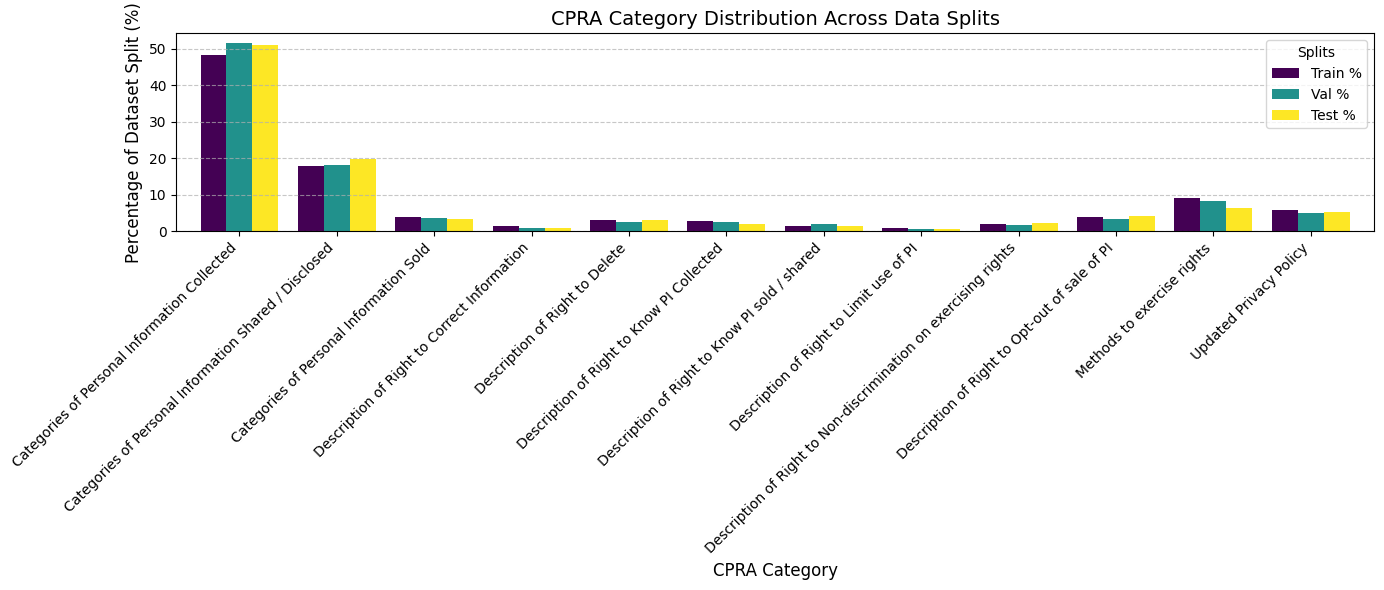

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Explicit Leakage Validation
print("--- Data Leakage Validation ---")
train_docs = set(train_df["doc_id"])
val_docs = set(val_df["doc_id"])
test_docs = set(test_df["doc_id"])

print(f"Overlap between Train & Val: {len(train_docs & val_docs)} documents")
print(f"Overlap between Train & Test: {len(train_docs & test_docs)} documents")
print(f"Overlap between Val & Test: {len(val_docs & test_docs)} documents\n")

# 2. Class Distribution Calculation
print("--- CPRA Category Distribution (%) ---")
train_dist = train_df['label'].value_counts(normalize=True) * 100
val_dist = val_df['label'].value_counts(normalize=True) * 100
test_dist = test_df['label'].value_counts(normalize=True) * 100

dist_df = pd.DataFrame({
    'Train %': train_dist,
    'Val %': val_dist,
    'Test %': test_dist
}).fillna(0).round(2)

display(dist_df)

# 3. Visualization
dist_df.plot(kind='bar', figsize=(14, 6), width=0.8, colormap='viridis')
plt.title('CPRA Category Distribution Across Data Splits', fontsize=14)
plt.ylabel('Percentage of Dataset Split (%)', fontsize=12)
plt.xlabel('CPRA Category', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Splits')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()